In [22]:
# Cell 1 - imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

In [23]:
# Cell 2 - USER SETTINGS

scope_file = r"combined_acq_full\20260320_163206_full_scope_all.npz"
wavemeter_file = r"combined_acq_full\20260320_163206_full_wavemeter.csv"

# -------------------------------------------------
# Wavemeter / TTL alignment
# -------------------------------------------------
ttl_threshold_v = 1.5

# -------------------------------------------------
# Dither suppression
# -------------------------------------------------
bin_size = 10
post_bin_savgol_window = 31
post_bin_savgol_poly = 3

# -------------------------------------------------
# Ramp finding on BINNED data
# -------------------------------------------------
scan_smooth_window = 101
coarse_block = 20
min_ramp_points = 150

edge_fraction = 0.12
eps = 1e-12

display_savgol_window = 15
display_savgol_poly = 3

max_shift = 8

In [24]:
# Cell 3 - loaders

import numpy as np
import pandas as pd

def load_scope_npz(path):
    d = np.load(path)

    t = d["time"]
    probe = d["ch1"]
    ref = d["ch2"]
    ttl = d["ch3"]
    scan = d["ch4"]

    mask = np.isfinite(t) & np.isfinite(probe) & np.isfinite(ref) & np.isfinite(ttl) & np.isfinite(scan)

    out = {
        "t": t[mask],
        "probe": probe[mask],
        "ref": ref[mask],
        "ttl": ttl[mask],
        "scan": scan[mask],
        "t_shot_launch_pc": float(d["t_shot_launch_pc"]),
        "t_shot_launch_perf_ns": int(d["t_shot_launch_perf_ns"]),
    }
    return out

def load_wavemeter_csv(path):
    wm = pd.read_csv(path)
    wm_ok = wm[wm["ok"] == True].copy()
    wm_ok["thz"] = pd.to_numeric(wm_ok["thz"], errors="coerce")
    wm_ok = wm_ok.dropna(subset=["thz"]).copy()

    if len(wm_ok) < 2:
        raise RuntimeError("Not enough valid wavemeter samples")

    wm_ok["t_rel_perf"] = (wm_ok["perf_ns"] - wm_ok["perf_ns"].iloc[0]) * 1e-9
    wm_ok["t_rel_pc"] = wm_ok["pc_time"] - wm_ok["pc_time"].iloc[0]
    return wm_ok

def bin_average_1d(arr, bin_size):
    n = len(arr) // bin_size
    return arr[:n * bin_size].reshape(n, bin_size).mean(axis=1)

In [25]:
# Cell 4 - load combined scope data

scope = load_scope_npz(scope_file)

t_raw = scope["t"]
probe_raw = scope["probe"]
ref_raw = scope["ref"]
ttl_raw = scope["ttl"]
scan_raw = scope["scan"]

print(f"Loaded raw points = {len(t_raw)}")
print(f"Raw probe mean = {np.mean(probe_raw):.6f} V")
print(f"Raw ref mean   = {np.mean(ref_raw):.6f} V")
print(f"Raw scan mean  = {np.mean(scan_raw):.6f} V")
print(f"Raw ttl mean   = {np.mean(ttl_raw):.6f} V")

t     = bin_average_1d(t_raw, bin_size)
probe = bin_average_1d(probe_raw, bin_size)
ref   = bin_average_1d(ref_raw, bin_size)
ttl   = bin_average_1d(ttl_raw, bin_size)
scan  = bin_average_1d(scan_raw, bin_size)

if post_bin_savgol_window >= len(probe):
    post_bin_savgol_window = len(probe) - 1 if len(probe) % 2 == 0 else len(probe)
if post_bin_savgol_window % 2 == 0:
    post_bin_savgol_window -= 1

print(f"Binned points = {len(t)}")
print(f"Binned probe mean = {np.mean(probe):.6f} V")
print(f"Binned ref mean   = {np.mean(ref):.6f} V")
print(f"Binned scan mean  = {np.mean(scan):.6f} V")
print(f"Binned ttl mean   = {np.mean(ttl):.6f} V")

Loaded raw points = 100000
Raw probe mean = 1.051804 V
Raw ref mean   = 1.009285 V
Raw scan mean  = 0.230511 V
Raw ttl mean   = 0.049591 V
Binned points = 10000
Binned probe mean = 1.051804 V
Binned ref mean   = 1.009285 V
Binned scan mean  = 0.230511 V
Binned ttl mean   = 0.049591 V


In [26]:
# Cell 5 - wavemeter alignment and interpolation onto scope time axis

wm_ok = load_wavemeter_csv(wavemeter_file)

# TTL detection on the RAW scope data, not the binned one
ttl_idx = np.where(ttl_raw > ttl_threshold_v)[0]
if len(ttl_idx) == 0:
    raise RuntimeError("No TTL pulse found in scope CH3")

i_ttl = ttl_idx[0]
t_scope_ttl = float(t_raw[i_ttl])

print(f"TTL detected at scope time = {t_scope_ttl:.9f} s")

# Approximate TTL location in wavemeter perf timebase
t_wm_ttl_approx = (
    (scope["t_shot_launch_perf_ns"] - int(wm_ok["perf_ns"].iloc[0])) * 1e-9
    + t_scope_ttl
)

print(f"Approx TTL in wavemeter perf timebase = {t_wm_ttl_approx:.9f} s")

# Map entire RAW scope time axis into wavemeter relative perf time
t_scope0_in_wm = t_wm_ttl_approx - t_scope_ttl
t_scope_in_wm_raw = t_scope0_in_wm + t_raw

# Interpolate wavemeter frequency onto RAW scope time axis
wm_t = wm_ok["t_rel_perf"].to_numpy(dtype=float)
wm_f = wm_ok["thz"].to_numpy(dtype=float)

freq_interp_raw = np.full_like(t_scope_in_wm_raw, np.nan, dtype=float)
valid = (t_scope_in_wm_raw >= wm_t.min()) & (t_scope_in_wm_raw <= wm_t.max())
freq_interp_raw[valid] = np.interp(t_scope_in_wm_raw[valid], wm_t, wm_f)

# Bin the interpolated frequency so it matches the binned scope arrays
freq_interp = bin_average_1d(freq_interp_raw, bin_size)

print(f"Interpolated frequency points (raw)   = {np.sum(np.isfinite(freq_interp_raw))}")
print(f"Interpolated frequency points (binned)= {np.sum(np.isfinite(freq_interp))}")
print(f"Frequency span (binned) = {np.nanmin(freq_interp):.9f} to {np.nanmax(freq_interp):.9f} THz")

TTL detected at scope time = 0.503400000 s
Approx TTL in wavemeter perf timebase = 1.094980000 s
Interpolated frequency points (raw)   = 100000
Interpolated frequency points (binned)= 10000
Frequency span (binned) = 355.802319000 to 355.805697000 THz


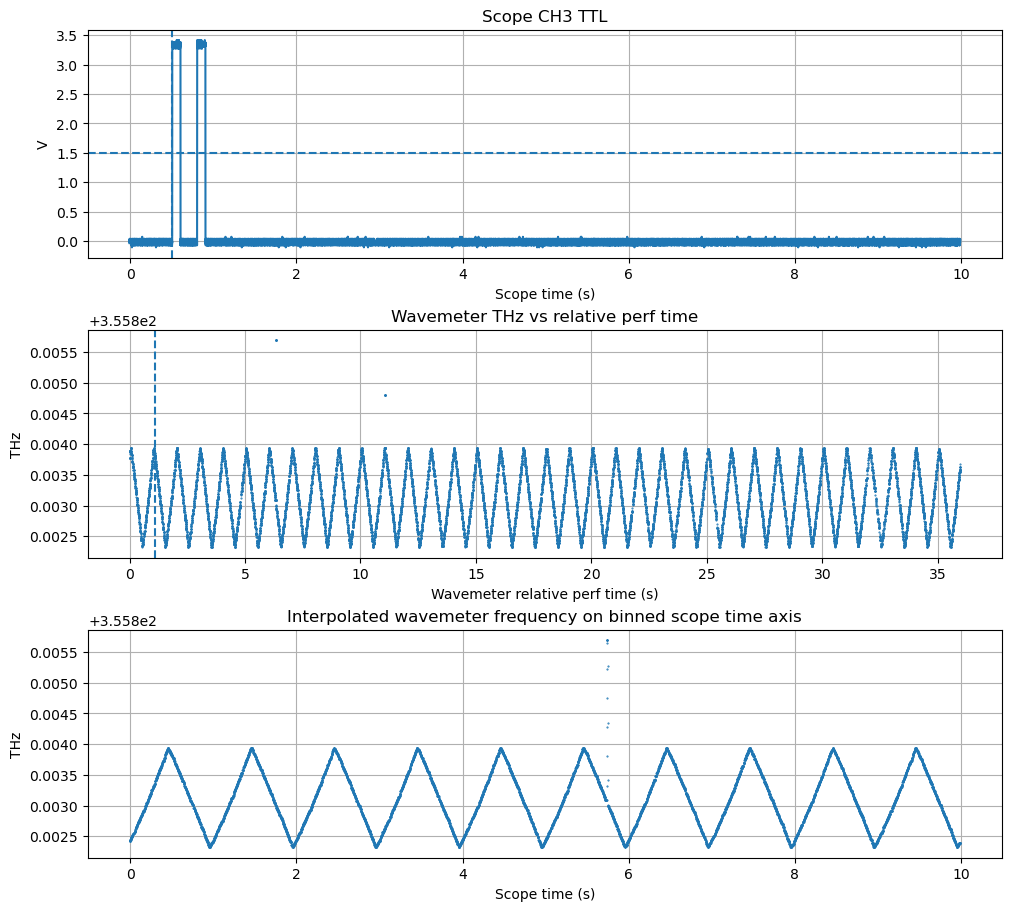

In [27]:
# Cell 5a - sanity plots for alignment

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)

axes[0].plot(t_raw, ttl_raw)
axes[0].axhline(ttl_threshold_v, linestyle="--")
axes[0].axvline(t_scope_ttl, linestyle="--")
axes[0].set_title("Scope CH3 TTL")
axes[0].set_xlabel("Scope time (s)")
axes[0].set_ylabel("V")

axes[1].plot(wm_ok["t_rel_perf"], wm_ok["thz"], ".", ms=1)
axes[1].axvline(t_wm_ttl_approx, linestyle="--")
axes[1].set_title("Wavemeter THz vs relative perf time")
axes[1].set_xlabel("Wavemeter relative perf time (s)")
axes[1].set_ylabel("THz")

axes[2].plot(t, freq_interp, ".", ms=1)
axes[2].set_title("Interpolated wavemeter frequency on binned scope time axis")
axes[2].set_xlabel("Scope time (s)")
axes[2].set_ylabel("THz")

plt.show()

Found 11 rising ramps


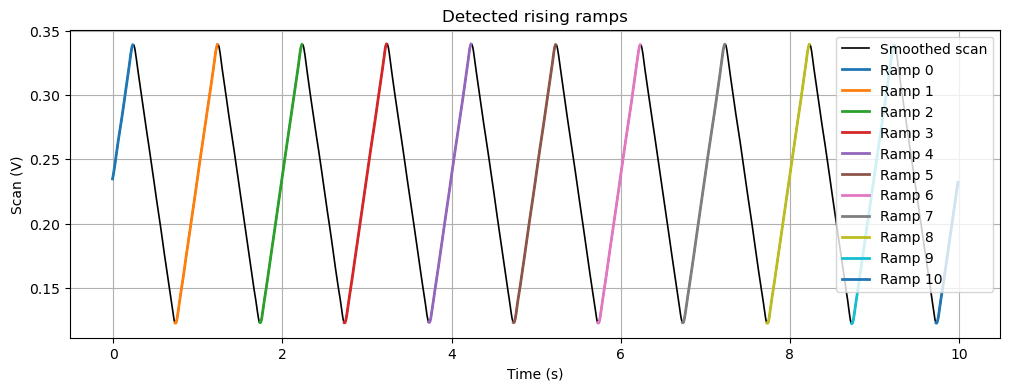

In [28]:
# Cell 6 - Rising ramps where derivative > 0
rising_state = dscan_coarse > 0

rising_ramps_coarse = []
in_run = False
start_idx = None

for i, state in enumerate(rising_state):
    if state and not in_run:
        in_run = True
        start_idx = i
    elif not state and in_run:
        rising_ramps_coarse.append((start_idx, i - 1))
        in_run = False

if in_run:
    rising_ramps_coarse.append((start_idx, len(rising_state) - 1))

ramp_slices = []
for a, b in rising_ramps_coarse:
    start = a * coarse_block
    end = min((b + 1) * coarse_block, len(scan_smooth) - 1)
    if (end - start) >= min_ramp_points:
        ramp_slices.append(slice(start, end))

print(f"Found {len(ramp_slices)} rising ramps")

plt.figure(figsize=(12, 4))
plt.plot(t, scan_smooth, color="black", lw=1.2, label="Smoothed scan")
for i, r in enumerate(ramp_slices):
    plt.plot(t[r], scan_smooth[r], lw=2, label=f"Ramp {i}")
plt.xlabel("Time (s)")
plt.ylabel("Scan (V)")
plt.title("Detected rising ramps")
plt.legend()
plt.show()

In [29]:
# Cell 7 - processing function

def process_rising_ramp(t_r, scan_r, freq_r, probe_r, ref_r, edge_fraction=0.12, eps=1e-12, max_shift=8):
    """
    Process one rising ramp with automatic small probe/ref sample alignment.

    Ramp detection / ordering is still based on scan voltage.
    Final spectroscopy axis is wavemeter frequency.
    """

    # -------------------------------------------------
    # 1. Find best small integer shift between probe and ref
    #    using ramp edges in time order
    # -------------------------------------------------
    n0 = len(scan_r)
    n_edge0 = max(10, int(edge_fraction * n0))
    edge_idx0 = np.r_[np.arange(n_edge0), np.arange(n0 - n_edge0, n0)]

    best_shift = 0
    best_score = np.inf

    for s in range(-max_shift, max_shift + 1):
        p_test = np.roll(probe_r, s)

        p_edge = p_test[edge_idx0]
        r_edge = ref_r[edge_idx0]

        k_test = np.mean(p_edge) / np.mean(r_edge)
        resid = p_edge - k_test * r_edge
        score = np.std(resid)

        if score < best_score:
            best_score = score
            best_shift = s

    # apply best shift to probe
    probe_r = np.roll(probe_r, best_shift)

    # -------------------------------------------------
    # 2. Sort by scan voltage (keep this)
    # -------------------------------------------------
    order = np.argsort(scan_r)

    x_scan = scan_r[order]
    x_freq = freq_r[order]
    tt = t_r[order]
    p = probe_r[order]
    r = ref_r[order]

    # keep only finite frequency points
    valid = np.isfinite(x_freq) & np.isfinite(x_scan) & np.isfinite(p) & np.isfinite(r) & np.isfinite(tt)

    x_scan = x_scan[valid]
    x_freq = x_freq[valid]
    tt = tt[valid]
    p = p[valid]
    r = r[valid]

    n = len(x_scan)
    if n < 20:
        raise RuntimeError("Ramp has too few valid points after frequency filtering")

    n_edge = max(20, int(edge_fraction * n))

    # -------------------------------------------------
    # 3. Scale reference to probe using ramp edges
    # -------------------------------------------------
    probe_edges = np.r_[p[:n_edge], p[-n_edge:]]
    ref_edges   = np.r_[r[:n_edge], r[-n_edge:]]

    k = np.mean(probe_edges) / np.mean(ref_edges)
    ref_scaled = k * r

    # -------------------------------------------------
    # 4. Build signals
    # -------------------------------------------------
    ratio = ref_scaled / (p + eps)
    od = np.log(ratio)
    diff = p - ref_scaled

    # -------------------------------------------------
    # 5. Linear / polynomial baseline from edges only
    #    IMPORTANT: baseline now fit in FREQUENCY space
    # -------------------------------------------------
    x_edge = np.r_[x_freq[:n_edge], x_freq[-n_edge:]]
    od_edge = np.r_[od[:n_edge], od[-n_edge:]]
    ratio_edge = np.r_[ratio[:n_edge], ratio[-n_edge:]]
    diff_edge = np.r_[diff[:n_edge], diff[-n_edge:]]

    od_coeff = np.polyfit(x_edge, od_edge, 3)
    od_baseline = np.polyval(od_coeff, x_freq)
    od_corr = od - od_baseline

    ratio_coeff = np.polyfit(x_edge, ratio_edge, 1)
    ratio_baseline = np.polyval(ratio_coeff, x_freq)
    ratio_corr = ratio / ratio_baseline

    diff_coeff = np.polyfit(x_edge, diff_edge, 1)
    diff_baseline = np.polyval(diff_coeff, x_freq)
    diff_corr = diff - diff_baseline

    return {
        "t": tt,
        "scan": x_scan,
        "freq": x_freq,
        "probe": p,
        "ref": r,
        "k": k,
        "best_shift": best_shift,
        "shift_score": best_score,
        "ref_scaled": ref_scaled,
        "ratio": ratio,
        "ratio_baseline": ratio_baseline,
        "ratio_corr": ratio_corr,
        "od": od,
        "od_baseline": od_baseline,
        "od_corr": od_corr,
        "diff": diff,
        "diff_baseline": diff_baseline,
        "diff_corr": diff_corr,
    }

In [30]:
# Cell 8 - process ramps

processed = []
for r in ramp_slices:
    processed.append(
        process_rising_ramp(
            t[r],
            scan[r],
            freq_interp[r],
            probe[r],
            ref[r],
            edge_fraction=edge_fraction,
            eps=eps,
            max_shift=max_shift
        )
    )

k_values = np.array([p["k"] for p in processed])

print(f"Processed {len(processed)} rising ramps")
print(f"k mean = {np.mean(k_values):.6f}")
print(f"k std  = {np.std(k_values):.6f}")

shift_values = np.array([p["best_shift"] for p in processed])
print(f"Best shifts per ramp = {shift_values.tolist()}")

Processed 11 rising ramps
k mean = 1.041015
k std  = 0.004435
Best shifts per ramp = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Users\dysprosium\AppData\Local\Temp\ipykernel_13508\2122540213.py:6: RankWarning: Polyfit may be poorly conditioned
  process_rising_ramp(
C:\Use

In [31]:
# Cell 8A - inspect individual rising ramps before averaging

# -------------------------------------------------
# USER CHOICE
# -------------------------------------------------
ramp_index = 3          # change this to inspect different ramps
show_all_ramps = True  # set True to overlay all ramps in one plot

if len(processed) == 0:
    raise RuntimeError("No processed ramps found. Run Cell 8 first.")

if ramp_index < 0 or ramp_index >= len(processed):
    raise IndexError(f"ramp_index must be between 0 and {len(processed)-1}")

# -------------------------------------------------
# 1. Print summary for each ramp
# -------------------------------------------------
print("Per-ramp summary")
print("----------------")
for i, p in enumerate(processed):
    print(
        f"Ramp {i:2d} | "
        f"N = {len(p['x']):4d} | "
        f"k = {p['k']:.6f} | "
        f"best_shift = {p['best_shift']:2d} | "
        f"shift_score = {p['shift_score']:.6e}"
    )

# -------------------------------------------------
# 2. Inspect one selected ramp in detail
# -------------------------------------------------
p = processed[ramp_index]

print("\nSelected ramp")
print("-------------")
print(f"Ramp index   = {ramp_index}")
print(f"N points     = {len(p['x'])}")
print(f"k            = {p['k']:.6f}")
print(f"best_shift   = {p['best_shift']}")
print(f"shift_score  = {p['shift_score']:.6e}")

fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# -------------------------------------------------
# Top panel: raw probe and scaled ref for this ramp
# -------------------------------------------------
ax[0].plot(p["freq"], p["probe"], label="Probe", lw=1.5)
ax[0].plot(p["freq"], p["ref_scaled"], label="Scaled ref", lw=1.5)
ax[0].set_ylabel("Photodiode signal (V)")
ax[0].set_title(f"Ramp {ramp_index}: raw probe vs scaled reference")
ax[0].legend()

# -------------------------------------------------
# Middle panel: uncorrected signals
# -------------------------------------------------
ax[1].plot(p["freq"], p["ratio"], label="Raw ratio = ref_scaled / probe", lw=1.5)
ax[1].plot(p["freq"], p["od"], label="Raw OD = ln(ref_scaled / probe)", lw=1.5)
ax[1].axhline(1.0, color="black", lw=0.8, alpha=0.5)
ax[1].axhline(0.0, color="grey", lw=0.8, alpha=0.5)
ax[1].set_ylabel("Raw spectroscopy signals")
ax[1].set_title(f"Ramp {ramp_index}: raw ratio and raw OD")
ax[1].legend()

# -------------------------------------------------
# Bottom panel: corrected signals
# -------------------------------------------------
ax[2].plot(p["freq"], p["ratio_corr"], label="Corrected ratio", lw=1.5)
ax[2].plot(p["freq"], p["od_corr"], label="Corrected OD", lw=1.5)
ax[2].axhline(1.0, color="black", lw=0.8, alpha=0.5)
ax[2].axhline(0.0, color="grey", lw=0.8, alpha=0.5)
ax[2].set_xlabel("Frequency (THz)")
ax[2].set_ylabel("Corrected signals")
ax[2].set_title(f"Ramp {ramp_index}: corrected ratio and corrected OD")
ax[2].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. Optional: overlay all corrected ramps without averaging
# -------------------------------------------------
if show_all_ramps:
    fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    for i, p in enumerate(processed):
        ax[0].plot(p["freq"], p["ratio_corr"], alpha=0.7, lw=1.0, label=f"Ramp {i}")
        ax[1].plot(p["freq"], p["od_corr"], alpha=0.7, lw=1.0, label=f"Ramp {i}")

    ax[0].axhline(1.0, color="black", lw=0.8)
    ax[1].axhline(0.0, color="black", lw=0.8)

    ax[0].set_ylabel("Corrected ratio")
    ax[0].set_title("All individual corrected ratio ramps")
    ax[1].set_ylabel("Corrected OD")
    ax[1].set_xlabel("Scan voltage (V)")
    ax[1].set_title("All individual corrected OD ramps")

    # only show legend if number of ramps is small enough
    if len(processed) <= 12:
        ax[0].legend(ncol=2, fontsize=9)
        ax[1].legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

Per-ramp summary
----------------


KeyError: 'x'

In [ ]:
# Cell 9 - Common x-axis in wavemeter frequency
x_min = max(np.min(p["freq"]) for p in processed)
x_max = min(np.max(p["freq"]) for p in processed)
common_x = np.linspace(x_min, x_max, 2500)

ratio_corr_matrix = []
od_corr_matrix = []
diff_corr_matrix = []

for p in processed:
    ratio_corr_matrix.append(np.interp(common_x, p["freq"], p["ratio_corr"]))
    od_corr_matrix.append(np.interp(common_x, p["freq"], p["od_corr"]))
    diff_corr_matrix.append(np.interp(common_x, p["freq"], p["diff_corr"]))

ratio_corr_matrix = np.array(ratio_corr_matrix)
od_corr_matrix = np.array(od_corr_matrix)
diff_corr_matrix = np.array(diff_corr_matrix)

ratio_mean = np.mean(ratio_corr_matrix, axis=0)
ratio_std  = np.std(ratio_corr_matrix, axis=0)

od_mean = np.mean(od_corr_matrix, axis=0)
od_std  = np.std(od_corr_matrix, axis=0)

diff_mean = np.mean(diff_corr_matrix, axis=0)
diff_std  = np.std(diff_corr_matrix, axis=0)

ratio_mean_s = savgol_filter(ratio_mean, display_savgol_window, display_savgol_poly)
od_mean_s    = savgol_filter(od_mean, display_savgol_window, display_savgol_poly)
diff_mean_s  = savgol_filter(diff_mean, display_savgol_window, display_savgol_poly)

: 

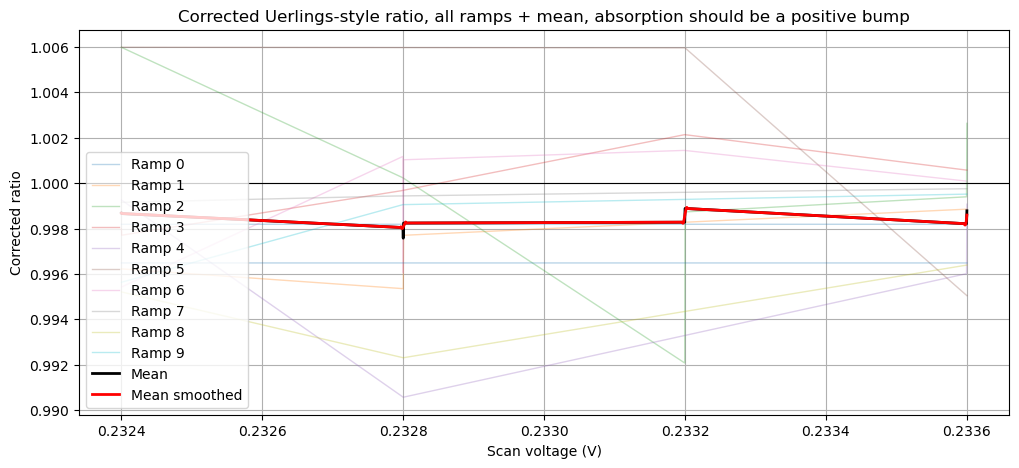

: 

In [ ]:
#Cell 10 - Ratio repeatability
plt.figure(figsize=(12, 5))
for i, y in enumerate(ratio_corr_matrix):
    plt.plot(common_x, y, alpha=0.3, lw=1, label=f"Ramp {i}" if i < 10 else None)

plt.plot(common_x, ratio_mean, color="black", lw=2, label="Mean")
plt.plot(common_x, ratio_mean_s, color="red", lw=2, label="Mean smoothed")
plt.axhline(1.0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Corrected Uerlings-style ratio, all ramps + mean, absorption should be a positive bump")
plt.legend()
plt.show()

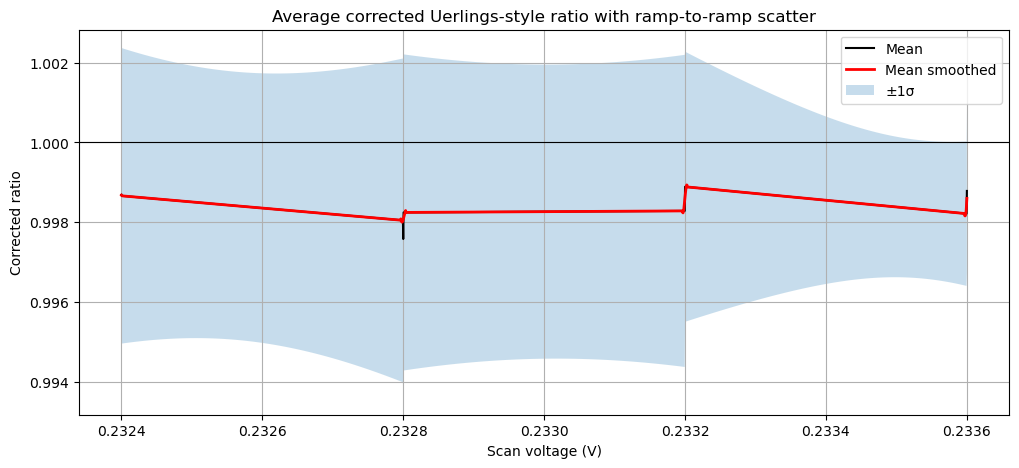

: 

In [ ]:
# Cell 11 - Mean + scatter band, ratio
plt.figure(figsize=(12, 5))
plt.plot(common_x, ratio_mean, color="black", lw=1.5, label="Mean")
plt.plot(common_x, ratio_mean_s, color="red", lw=2, label="Mean smoothed")
plt.fill_between(common_x, ratio_mean - ratio_std, ratio_mean + ratio_std, alpha=0.25, label="±1σ")
plt.axhline(1.0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("Corrected ratio")
plt.title("Average corrected Uerlings-style ratio with ramp-to-ramp scatter")
plt.legend()
plt.show()

In [ ]:
# Cell 12 - Full-range peak search using OD as primary detection
# Broad-feature detector using integrated OD area

from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Search the FULL common_x range
# -------------------------------------------------
x_search = common_x

ratio_search = ratio_mean_s
ratio_std_search = ratio_std

od_search = od_mean_s
od_std_search = od_std

# Detection-only smoothing
detect_window = 61
detect_poly   = 3

ratio_detect = savgol_filter(ratio_search, detect_window, detect_poly)
od_detect    = savgol_filter(od_search,    detect_window, detect_poly)

# -------------------------------------------------
# 2. Detect broad OD regions
# -------------------------------------------------
baseline = np.percentile(od_detect, 40)
noise = np.std(od_detect - baseline)
threshold = baseline + 0.5 * noise
min_region_points = 12

above = od_detect > threshold

regions = []
in_region = False
start = None

for i, flag in enumerate(above):
    if flag and not in_region:
        start = i
        in_region = True
    elif not flag and in_region:
        end = i - 1
        if end - start + 1 >= min_region_points:
            regions.append((start, end))
        in_region = False

if in_region:
    end = len(above) - 1
    if end - start + 1 >= min_region_points:
        regions.append((start, end))

# -------------------------------------------------
# 3. Score regions by integrated OD area
# -------------------------------------------------
candidates = []
window = 12

for start, end in regions:
    region_slice = slice(start, end + 1)

    x_region = x_search[region_slice]
    od_region = od_detect[region_slice]
    od_std_region = od_std_search[region_slice]

    # representative peak position
    local_idx = np.argmax(od_region)
    op = start + local_idx

    x_o = x_search[op]
    y_od = od_detect[op]

    # integrated OD area above threshold
    od_excess = np.clip(od_region - threshold, 0, None)
    od_area = np.trapezoid(od_excess, x_region)

    # noise estimate
    mean_std = np.mean(od_std_region)
    region_width = x_region[-1] - x_region[0] if len(x_region) > 1 else 0.0
    od_area_noise = mean_std * max(region_width, 1e-12)

    area_snr = od_area / od_area_noise if od_area_noise > 0 else np.nan

    # ratio support
    i_min = max(0, op - window)
    i_max = min(len(ratio_search), op + window + 1)

    local_ratio = ratio_detect[i_min:i_max]
    local_ratio_std = ratio_std_search[i_min:i_max]

    ratio_val = np.min(local_ratio)
    ratio_noise = np.mean(local_ratio_std)
    snr_ratio_dip = (1.0 - ratio_val) / ratio_noise if ratio_noise > 0 else np.nan

    candidates.append({
        "x": x_o,
        "od": y_od,
        "od_area": od_area,
        "area_snr": area_snr,
        "ratio": ratio_val,
        "ratio_dip_snr": snr_ratio_dip,
        "region_start_x": x_search[start],
        "region_end_x": x_search[end]
    })

# -------------------------------------------------
# 4. Filter strong regions
# -------------------------------------------------
candidates = sorted(candidates, key=lambda d: d["x"])

# Keep the strongest regions by AREA, not SNR
candidates_sorted_by_area = sorted(candidates, key=lambda d: d["od_area"], reverse=True)

# take top N regions
max_area = candidates_sorted_by_area[0]["od_area"]

strong_peaks = [
    p for p in candidates_sorted_by_area
    if p["od_area"] >= 0.3 * max_area
]

# -------------------------------------------------
# 5. Print results
# -------------------------------------------------
print(f"Found {len(candidates)} OD-identified broad regions across the full scan")
print(f"Stronger regions with area SNR >= 1.0: {len(strong_peaks)}\n")

print("All candidates:\n")
for i, p in enumerate(candidates):
    print(f"Peak {i+1}")
    print(f"  Frequency         = {p['x']:.6f} THz")
    print(f"  Region span     = {p['region_start_x']:.6f} to {p['region_end_x']:.6f} THz")
    print(f"  OD peak         = {p['od']:.6f}")
    print(f"  OD area         = {p['od_area']:.6e}   (area SNR ≈ {p['area_snr']:.2f})")
    print(f"  Ratio local dip = {p['ratio']:.6f}   (dip SNR ≈ {p['ratio_dip_snr']:.2f})")
    print()

print("Stronger peaks only:\n")
for i, p in enumerate(strong_peaks):
    print(f"Peak {i+1}")
    print(f"  Frequency         = {p['x']:.6f} THz")
    print(f"  Region span     = {p['region_start_x']:.6f} to {p['region_end_x']:.6f} THz")
    print(f"  OD peak         = {p['od']:.6f}")
    print(f"  OD area         = {p['od_area']:.6e}   (area SNR ≈ {p['area_snr']:.2f})")
    print(f"  Ratio local dip = {p['ratio']:.6f}   (dip SNR ≈ {p['ratio_dip_snr']:.2f})")
    print()

# -------------------------------------------------
# 6. Plot results
# -------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Ratio plot
ax[0].plot(common_x, ratio_mean_s, color="red", lw=2, label="Mean smoothed ratio")
for p in strong_peaks:
    ax[0].axvline(p["x"], color="blue", ls="--", alpha=0.6)
ax[0].axhline(1.0, color="black", lw=0.8)
ax[0].set_ylabel("Corrected ratio")
ax[0].set_title("Full-range ratio")
ax[0].legend()

# OD plot
ax[1].plot(common_x, od_mean_s, color="purple", lw=2, label="Mean smoothed OD")
for p in strong_peaks:
    ax[1].axvline(p["x"], color="blue", ls="--", alpha=0.6)
ax[1].axhline(0.0, color="black", lw=0.8)
ax[1].set_xlabel("Frequency (THz)")
ax[1].set_ylabel("Corrected OD-like signal")
ax[1].set_title("Full-range OD")
ax[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 7. Diagnostic plot (VERY IMPORTANT)
# -------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(common_x, od_mean_s, label="OD (plotting)", alpha=0.5)
plt.plot(common_x, od_detect, label="OD (detection)", lw=2)

for p in strong_peaks:
    plt.axvspan(p["region_start_x"], p["region_end_x"], color="orange", alpha=0.2)

plt.axhline(threshold, color="green", ls="--", label=f"threshold = {threshold}")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Frequency (THz)")
plt.ylabel("OD-like signal")
plt.title("Broad region detection")
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: module 'numpy' has no attribute 'trapezoid'

: 

In [ ]:
# Cell 13 - 1-peak Gaussian fit on the strongest ratio feature

from scipy.optimize import curve_fit

# -------------------------------------------------
# 1. Define model: linear background + one Gaussian bump
# -------------------------------------------------
def gauss_plus_line(x, c0, c1, A, x0, sigma):
    return c0 + c1 * x + A * np.exp(-0.5 * ((x - x0) / sigma) ** 2)

# -------------------------------------------------
# 2. Require at least one strong peak from Cell 12
# -------------------------------------------------
if len(strong_peaks) == 0:
    raise RuntimeError("No strong_peaks found in Cell 12, cannot do 1-peak fit.")

# Use the strongest ratio peak as the first fitting target
peak0 = max(strong_peaks, key=lambda p: p["ratio_dip_snr"])
x0_guess = peak0["x"]

print(f"Using strongest peak at f = {x0_guess:.9f} THz as the initial 1-peak fit target")

# -------------------------------------------------
# 3. Define a LOCAL fitting window around that peak
#    Keep this local so we are not trying to fit the whole scan at once
# -------------------------------------------------
fit_half_width = 0.00015  # THz

mask_fit = (common_x >= x0_guess - fit_half_width) & (common_x <= x0_guess + fit_half_width)

x_fit = common_x[mask_fit]
y_fit = ratio_mean_s[mask_fit]

if len(x_fit) < 20:
    raise RuntimeError("Fit window is too small. Check common_x or fit_half_width.")

# -------------------------------------------------
# 4. Initial guesses
# -------------------------------------------------
# baseline from edges of local window
n_edge = max(3, len(x_fit) // 8)

x_edge = np.r_[x_fit[:n_edge], x_fit[-n_edge:]]
y_edge = np.r_[y_fit[:n_edge], y_fit[-n_edge:]]

# linear background guess
c1_guess, c0_guess = np.polyfit(x_edge, y_edge, 1)

baseline_guess = c0_guess + c1_guess * x_fit
A_guess = max(y_fit - baseline_guess)
sigma_guess = 0.010  # volts, deliberately moderate initial width

p0 = [c0_guess, c1_guess, A_guess, x0_guess, sigma_guess]

# -------------------------------------------------
# 5. Bounds
# -------------------------------------------------
lower_bounds = [
    0.98,          # c0
    -1.0,          # c1
    0.0,           # A must be positive for absorption bump in ratio
    x0_guess - 0.02,
    0.002          # sigma
]

upper_bounds = [
    1.05,          # c0
    1.0,           # c1
    0.05,          # A
    x0_guess + 0.02,
    0.050          # sigma
]

# -------------------------------------------------
# 6. Fit
# -------------------------------------------------
popt, pcov = curve_fit(
    gauss_plus_line,
    x_fit,
    y_fit,
    p0=p0,
    bounds=(lower_bounds, upper_bounds),
    maxfev=20000
)

c0_fit, c1_fit, A_fit, x0_fit, sigma_fit = popt
y_model = gauss_plus_line(x_fit, *popt)
resid = y_fit - y_model

# Gaussian FWHM
fwhm_fit = 2.35482 * sigma_fit

# crude uncertainties from covariance
perr = np.sqrt(np.diag(pcov))
c0_err, c1_err, A_err, x0_err, sigma_err = perr
fwhm_err = 2.35482 * sigma_err

# residual RMS
resid_rms = np.sqrt(np.mean(resid**2))

print("\n1-peak fit results")
print("------------------")
print(f"Centre x0     = {x0_fit:.6f} ± {x0_err:.6f} V")
print(f"Amplitude A   = {A_fit:.6f} ± {A_err:.6f}")
print(f"Sigma         = {sigma_fit:.6f} ± {sigma_err:.6f} V")
print(f"FWHM          = {fwhm_fit:.6f} ± {fwhm_err:.6f} V")
print(f"Background c0 = {c0_fit:.6f} ± {c0_err:.6f}")
print(f"Background c1 = {c1_fit:.6f} ± {c1_err:.6f}")
print(f"Residual RMS  = {resid_rms:.6f}")

# -------------------------------------------------
# 7. Plot fit + residuals
# -------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(x_fit, y_fit, "o", ms=3, label="Ratio data in local window")
ax[0].plot(x_fit, y_model, "-", lw=2, label="1-peak Gaussian + line fit")
ax[0].axvline(x0_fit, color="blue", ls="--", label=f"Fit centre = {x0_fit:.6f} V")
ax[0].axhline(1.0, color="black", lw=0.8)
ax[0].set_ylabel("Corrected ratio")
ax[0].set_title("1-peak fit on strongest ratio feature")
ax[0].legend()

ax[1].plot(x_fit, resid, "-", lw=1.5)
ax[1].axhline(0.0, color="black", lw=0.8)
ax[1].set_xlabel("Scan voltage (V)")
ax[1].set_ylabel("Residual")
ax[1].set_title("Fit residuals")

plt.tight_layout()
plt.show()

NameError: name 'strong_peaks' is not defined

: 

: 